<a href="https://colab.research.google.com/github/jdaltongit/CSCI580_Spring26_Group7/blob/main/FinalProject/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Clone our group's project repo
!git clone https://github.com/Christian-T-U/Final_Project_CSCI_580.git

# Clone the repo with ALL class digit images
!git clone https://github.com/boshen-csuchico/Handwritten-Digits-Spring-2026.git

fatal: destination path 'Final_Project_CSCI_580' already exists and is not an empty directory.
fatal: destination path 'Handwritten-Digits-Spring-2026' already exists and is not an empty directory.


In [13]:
# imports
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [14]:
# Load and preprocess the MNIST dataset using PyTorch's torchvision library
# Based on professor's LoadImage.ipynb reference notebook
# Training set is split 80/20 into training and validation as shown in ModelTuning slides

# Normalize pixel values from [0,255] to [-1,1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download full training set and test set
trainset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=True, transform=transform)
testset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=False, transform=transform)

# Split training set into 80% train and 20% validation
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_data, val_data = torch.utils.data.random_split(trainset, [train_size, val_size])

# Create data loaders
trainloader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)
valloader = torch.utils.data.DataLoader(val_data, batch_size=128, shuffle=False)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

print('Training batches:', len(trainloader))
print('Validation batches:', len(valloader))
print('Test batches:', len(testloader))

Training batches: 375
Validation batches: 94
Test batches: 79


In [15]:
# This function takes an image name and returns the data as an ndarray
def ProjectDataLoader(folder='./Handwritten-Digits-Spring-2026/digits'):
    images, labels = [], []
    for fname in sorted(os.listdir(folder)):
        if not fname.endswith('.png'):
            continue
        try:
            label = int(fname.split('-')[0])
        except ValueError:
            continue
        img = Image.open(os.path.join(folder, fname)).convert('L')
        img = img.resize((28, 28), Image.LANCZOS)
        images.append(np.array(img))
        labels.append(label)
    print(f"Loaded {len(images)} group images")
    return np.array(images), np.array(labels)

group_images, group_labels = ProjectDataLoader()

Loaded 290 group images


In [16]:
class DigitDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx].astype(np.uint8))
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

group_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

group_dataset = DigitDataset(group_images, group_labels, group_transform)
group_loader  = DataLoader(group_dataset, batch_size=128, shuffle=False)
print(f"Group loader ready: {len(group_dataset)} samples")

Group loader ready: 290 samples


In [17]:
# MLP Network class: 784 -> 512 -> 128 -> 64 -> 10
# Uses ReLU activations for hidden layers and LogSoftmax for output
# LogSoftmax is used with NLLLoss as shown in class slides
# class structure for nn
class Network(nn.Module):
    # making of network
    def __init__(self):
        super().__init__() # try experimenting with different layer combinations for better results
        self.fc1 = nn.Linear(784,512)
        self.fc2 = nn.Linear(512,128)
        self.fc3 = nn.Linear(128,64)
        self.output = nn.Linear(64,10)
    # feedforward process
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.log_softmax(self.output(x), dim=1)
        return x

In [18]:
# Prelims
# Define hyperparameters, model, optimizer, and loss function
# Hyperparameter values will be tuned through experimentation

# Gets all image filenames and store them in filenames
directory = './Handwritten-Digits-Spring-2026/digits/'
filenames = os.listdir(directory)

# Define variables and model
epochs = 30
model = Network()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.NLLLoss()

# Store loss for each step (for plotting later)
trainLoss = []
valLoss = []
print(f"Training on epochs={epochs}, optimizer=Adam, lr=0.001")

Training on epochs=30, optimizer=Adam, lr=0.001


In [19]:
# Main loop — trains on MNIST dataset with validation after each epoch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Training on: {device}")

for epoch in range(epochs):
    # Training phase
    model.train()
    running_train_loss = 0.0
    for images, labels in trainloader:
        images = images.view(images.shape[0], -1).to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = loss_fn(output, labels) # NLLLoss
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    # Validation phase (after each epoch)
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in valloader:
            images = images.view(images.shape[0], -1).to(device)
            labels = labels.to(device)
            output = model(images)
            loss = loss_fn(output, labels)
            running_val_loss += loss.item()

    # Record and print epoch results
    avg_train_loss = running_train_loss / len(trainloader)
    avg_val_loss   = running_val_loss   / len(valloader)
    trainLoss.append(avg_train_loss)
    valLoss.append(avg_val_loss)
    print(f'Epoch {epoch+1}/{epochs} — Train Loss: {avg_train_loss:.4f} — Val Loss: {avg_val_loss:.4f}')

torch.save(model.state_dict(), 'best_model.pth')
print("\nTraining complete. Model saved.")

Training on: cpu
Epoch 1/30 — Train Loss: 0.4450 — Val Loss: 0.2223
Epoch 2/30 — Train Loss: 0.1896 — Val Loss: 0.1495
Epoch 3/30 — Train Loss: 0.1329 — Val Loss: 0.1213
Epoch 4/30 — Train Loss: 0.1025 — Val Loss: 0.1073
Epoch 5/30 — Train Loss: 0.0871 — Val Loss: 0.0847
Epoch 6/30 — Train Loss: 0.0722 — Val Loss: 0.1090
Epoch 7/30 — Train Loss: 0.0634 — Val Loss: 0.1049
Epoch 8/30 — Train Loss: 0.0602 — Val Loss: 0.0847
Epoch 9/30 — Train Loss: 0.0482 — Val Loss: 0.1166
Epoch 10/30 — Train Loss: 0.0433 — Val Loss: 0.1006
Epoch 11/30 — Train Loss: 0.0415 — Val Loss: 0.0883
Epoch 12/30 — Train Loss: 0.0368 — Val Loss: 0.1014
Epoch 13/30 — Train Loss: 0.0345 — Val Loss: 0.0945
Epoch 14/30 — Train Loss: 0.0330 — Val Loss: 0.0961
Epoch 15/30 — Train Loss: 0.0302 — Val Loss: 0.1067
Epoch 16/30 — Train Loss: 0.0293 — Val Loss: 0.1059
Epoch 17/30 — Train Loss: 0.0249 — Val Loss: 0.1086
Epoch 18/30 — Train Loss: 0.0268 — Val Loss: 0.1258
Epoch 19/30 — Train Loss: 0.0197 — Val Loss: 0.0818
Epoc

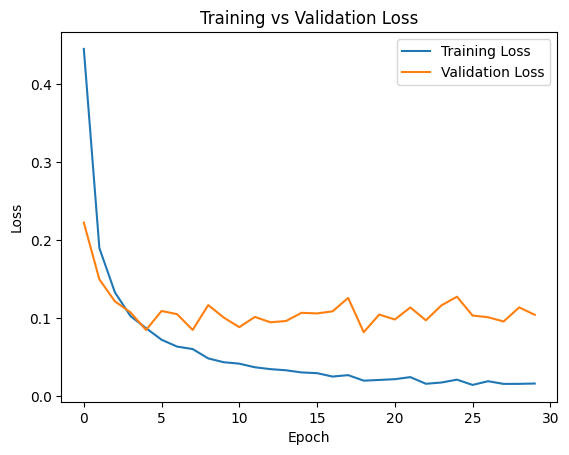

In [20]:
# Plot training and validation loss per epoch
plt.plot(trainLoss, label='Training Loss')
plt.plot(valLoss,   label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

MNIST Test Accuracy: 97.80%
MNIST Error Rate:    2.20%

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.96      0.99      0.97       982
           5       0.99      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.95      0.98      0.97      1028
           8       0.98      0.97      0.98       974
           9       1.00      0.93      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



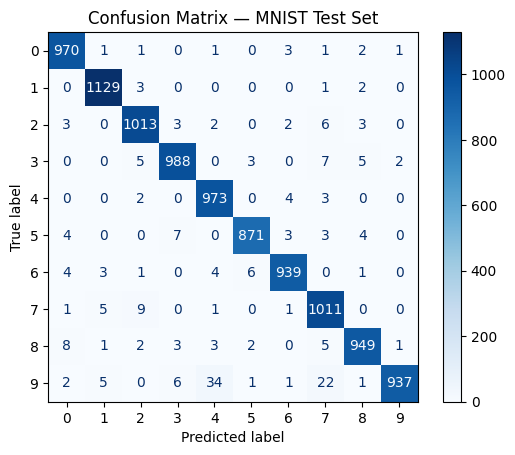

MNIST Per-Digit Accuracy:
Digit   Correct   Total     Accuracy
--------------------------------------
0       970       980       98.98%
1       1129      1135      99.47%
2       1013      1032      98.16%
3       988       1010      97.82%
4       973       982       99.08%
5       871       892       97.65%
6       939       958       98.02%
7       1011      1028      98.35%
8       949       974       97.43%
9       937       1009      92.86%


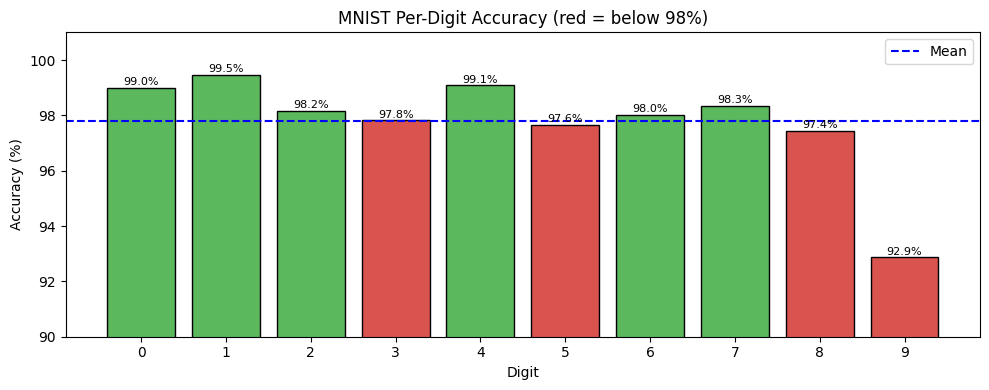

Group Digit Accuracy: 60.34%
Group Error Rate:     39.66%

              precision    recall  f1-score   support

           0       1.00      0.62      0.77        29
           1       0.41      0.62      0.49        29
           2       0.66      0.72      0.69        29
           3       0.73      0.76      0.75        29
           4       0.49      0.72      0.58        29
           5       0.50      0.55      0.52        29
           6       0.75      0.62      0.68        29
           7       0.43      0.52      0.47        29
           8       0.82      0.62      0.71        29
           9       0.80      0.28      0.41        29

    accuracy                           0.60       290
   macro avg       0.66      0.60      0.61       290
weighted avg       0.66      0.60      0.61       290



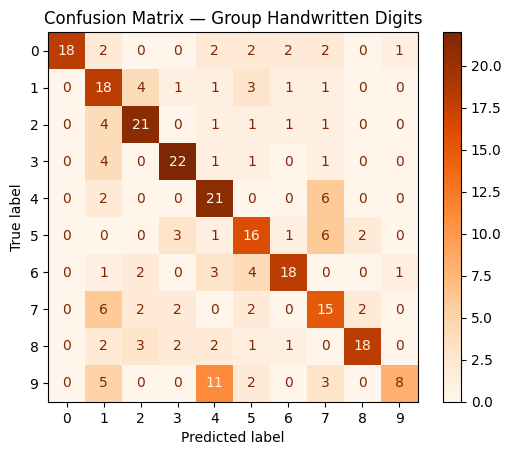

Group Per-Digit Accuracy:
Digit   Correct   Total     Accuracy
--------------------------------------
0       18        29        62.07%
1       18        29        62.07%
2       21        29        72.41%
3       22        29        75.86%
4       21        29        72.41%
5       16        29        55.17%
6       18        29        62.07%
7       15        29        51.72%
8       18        29        62.07%
9       8         29        27.59%


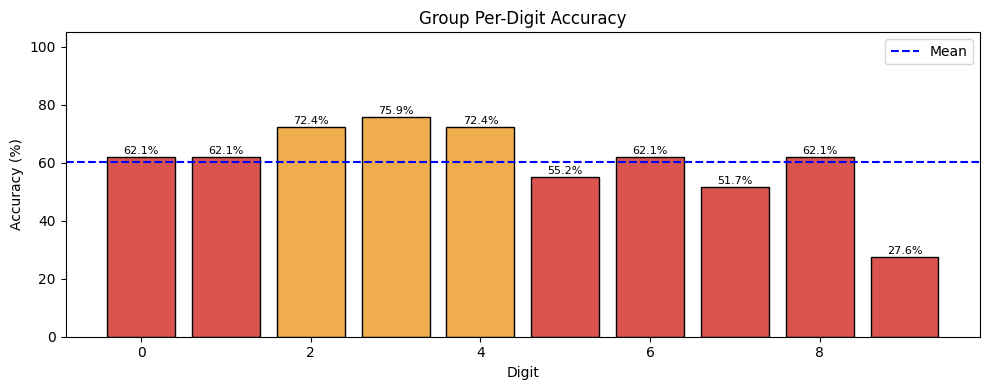

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import defaultdict

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

correct = 0
total = 0
all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.view(images.shape[0], -1).to(device)
        outputs = model(images)
        predicted = outputs.argmax(dim=1).cpu()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(predicted.numpy())
        all_true.extend(labels.numpy())

print(f"MNIST Test Accuracy: {100 * correct / total:.2f}%")
print(f"MNIST Error Rate:    {100 * (1 - correct/total):.2f}%")
print()
print(classification_report(all_true, all_preds, target_names=[str(i) for i in range(10)]))

ConfusionMatrixDisplay(confusion_matrix(all_true, all_preds), display_labels=list(range(10))).plot(cmap='Blues')
plt.title('Confusion Matrix — MNIST Test Set')
plt.show()

# Per-digit accuracy — MNIST ──────────────────────────────────────────
class_correct = defaultdict(int)
class_total   = defaultdict(int)

with torch.no_grad():
    for images, labels in testloader:
        images = images.view(images.shape[0], -1).to(device)
        predicted = model(images).argmax(dim=1).cpu()
        for pred, true in zip(predicted.numpy(), labels.numpy()):
            class_total[true]   += 1
            class_correct[true] += int(pred == true)

print('MNIST Per-Digit Accuracy:')
print(f'{"Digit":<8}{"Correct":<10}{"Total":<10}{"Accuracy"}')
print('-' * 38)
for d in range(10):
    acc = 100 * class_correct[d] / class_total[d]
    print(f'{d:<8}{class_correct[d]:<10}{class_total[d]:<10}{acc:.2f}%')

digits = list(range(10))
accs   = [100 * class_correct[d] / class_total[d] for d in digits]
colors = ['#d9534f' if a < 98 else '#5cb85c' for a in accs]
plt.figure(figsize=(10, 4))
bars = plt.bar(digits, accs, color=colors, edgecolor='black')
plt.axhline(sum(accs)/10, color='blue', linestyle='--', label='Mean')
for bar, a in zip(bars, accs):
    plt.text(bar.get_x()+bar.get_width()/2, a+.1, f'{a:.1f}%', ha='center', fontsize=8)
plt.xlabel('Digit'); plt.ylabel('Accuracy (%)')
plt.title('MNIST Per-Digit Accuracy (red = below 98%)')
plt.xticks(digits); plt.ylim([90, 101]); plt.legend(); plt.tight_layout(); plt.show()
# ─────────────────────────────────────────────────────────────────────────────

correct = 0
total = 0
g_preds = []
g_true = []

with torch.no_grad():
    for images, labels in group_loader:
        images = images.view(images.shape[0], -1).to(device)
        outputs = model(images)
        predicted = outputs.argmax(dim=1).cpu()
        correct += (predicted.numpy() == np.array(labels)).sum()
        total += len(labels)
        g_preds.extend(predicted.numpy())
        g_true.extend(labels)

print(f"Group Digit Accuracy: {100 * correct / total:.2f}%")
print(f"Group Error Rate:     {100 * (1 - correct/total):.2f}%")
print()
print(classification_report(g_true, g_preds, target_names=[str(i) for i in range(10)]))

ConfusionMatrixDisplay(confusion_matrix(g_true, g_preds), display_labels=list(range(10))).plot(cmap='Oranges')
plt.title('Confusion Matrix — Group Handwritten Digits')
plt.show()

# NEW: Per-digit accuracy — group set ──────────────────────────────────────
g_class_correct = defaultdict(int)
g_class_total   = defaultdict(int)

with torch.no_grad():
    for images, labels in group_loader:
        images = images.view(images.shape[0], -1).to(device)
        predicted = model(images).argmax(dim=1).cpu().numpy()
        for pred, true in zip(predicted, labels):
            g_class_total[int(true)]   += 1
            g_class_correct[int(true)] += int(pred == true)

present = sorted(g_class_total.keys())
print('Group Per-Digit Accuracy:')
print(f'{"Digit":<8}{"Correct":<10}{"Total":<10}{"Accuracy"}')
print('-' * 38)
for d in present:
    acc = 100 * g_class_correct[d] / g_class_total[d]
    print(f'{d:<8}{g_class_correct[d]:<10}{g_class_total[d]:<10}{acc:.2f}%')

g_accs   = [100 * g_class_correct[d] / g_class_total[d] for d in present]
g_colors = ['#d9534f' if a<70 else '#f0ad4e' if a<90 else '#5cb85c' for a in g_accs]
plt.figure(figsize=(10, 4))
bars = plt.bar(present, g_accs, color=g_colors, edgecolor='black')
plt.axhline(sum(g_accs)/len(g_accs), color='blue', linestyle='--', label='Mean')
for bar, a in zip(bars, g_accs):
    plt.text(bar.get_x()+bar.get_width()/2, a+1, f'{a:.1f}%', ha='center', fontsize=8)
plt.xlabel('Digit'); plt.ylabel('Accuracy (%)')
plt.title('Group Per-Digit Accuracy')
plt.ylim([0, 105]); plt.legend(); plt.tight_layout(); plt.show()

In [22]:
# Per-group accuracy (filename format: digit-groupID-memberID.png)
folder = './Handwritten-Digits-Spring-2026/digits'
pg_correct = defaultdict(int)
pg_total = defaultdict(int)

model.eval()
with torch.no_grad():
    for fname in sorted(os.listdir(folder)):
        if not fname.endswith('.png'):
            continue
        parts = fname.split('-')
        try:
            label = int(parts[0])
            group_id = int(parts[1])
        except (ValueError, IndexError):
            continue
        img = Image.open(os.path.join(folder, fname)).convert('L')
        img = img.resize((28, 28), Image.LANCZOS)
        tensor = group_transform(img).view(1, -1).to(device)
        pred = model(tensor).argmax(dim=1).item()
        pg_total[group_id] += 1
        pg_correct[group_id] += int(pred == label)

print(f'{"Group":<8}{"Correct":<10}{"Total":<10}{"Accuracy"}')
print('-' * 38)
for gid in sorted(pg_total):
    print(f'{gid:<8}{pg_correct[gid]:<10}{pg_total[gid]:<10}{100*pg_correct[gid]/pg_total[gid]:.2f}%')

Group   Correct   Total     Accuracy
--------------------------------------
1       5         20        25.00%
2       14        30        46.67%
3       15        40        37.50%
4       18        30        60.00%
5       23        30        76.67%
6       23        30        76.67%
7       19        30        63.33%
8       28        40        70.00%
9       30        40        75.00%
